# Cross-Position Scale Comparability

Tests whether the rating scale means the same thing across positions - is it
"easier" for a striker to reach a given rating than a centre-back, for an
equivalently elite-relative-to-peers underlying performance? Not covered by any
single section of the critical review (3.0-3.9), though it borrows from three:
3.5's scrutiny of hand-set parameters (the goal/assist bonus coefficients
specifically), 3.7's known-groups stress-test logic, and 3.3's output-
distribution diagnostics extended to be position-stratified.

**The trap this design is built to avoid:** comparing real achieved ratings or
ceilings by position directly is circular - if strikers genuinely had a better
season than centre-backs this save, a higher ST ceiling would be a true
reflection of that, not evidence the scale is unfair. The fix: compare final
rating at matched *within-position percentiles* of an independent quality
measure - the pre-bonus, pre-sigmoid weighted z-scored dot product
(`raw_score`), captured directly from the live service rather than
reconstructed externally (avoids re-implementing Bayesian smoothing by hand).
"95th percentile of raw_score among STs" and "95th percentile among CBs" are
each genuinely elite-for-their-own-role, independent of how generously either
position's bonus structure subsequently treats that.

**Scope decision:** restricted to single-position performances only.
`_calculate_dot_product` runs once per position in a multi-position player's
blend, so capturing it cleanly requires excluding multi-position performances
rather than risking conflating two positions' raw_scores from one rating call.

**Reference position:** CM, not arbitrarily chosen - `performance_weights.json`'s
own comment calls it the system's neutral baseline ("all football blocks
equal"), the position every other weight vector deliberately deviates from.

In [9]:
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Define the project root
project_root = Path("..").resolve().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

matches_path = project_root / "data" / "valencia_cf_1" / "matches.json"

from src.services.analytics.match_ratings_service import MatchRatingsService

In [10]:
RANDOM_SEED = 42
N_BOOTSTRAP_RESAMPLES = 5000

# Percentile binning for the within-position comparison - deciles, enough
# granularity to see curve shape without fragmenting the smaller position
# groups (ST, CDM) into bins too thin to trust.
N_PERCENTILE_BINS = 10
MIN_SAMPLES_PER_BIN = 15  # below this, flag the bin as too thin to interpret

# CM is the system's own designated neutral baseline - see intro above - not
# an arbitrary pick, the reference every other position gets compared against.
REFERENCE_POSITION = 'CM'

# Interpretation bands for the average gap (in rating points) between a
# position's curve and CM's at matched within-position raw_score percentiles -
# decided before seeing results. Loosely anchored against the critical
# review's own characterisation of the ~0.2-0.3 half-length gap as a "mild
# reliability leak" - a comparable scale for a comparable kind of judgement.
SCALE_GAP_BANDS = {
    'comparable':              (0.0, 0.3),
    'mild_divergence':         (0.3, 0.6),
    'substantial_divergence':  (0.6, 10.0),
}

def classify_scale_gap(gap: float) -> str:
    abs_gap = abs(gap)
    return next(
        (
            label
            for label, (lo, hi) in SCALE_GAP_BANDS.items()
            if lo <= abs_gap < hi
        ),
        'substantial_divergence',
    )

In [11]:
with open(project_root / "config" / "performance_weights.json", "r") as f:
    weights = json.load(f)

with open(project_root / "config" / "performance_means_stds.json", "r") as f:
    means_stds = json.load(f)

with open(matches_path, "r") as f:
    data = json.load(f)

In [12]:
class RawScoreCapturingService(MatchRatingsService):
    """Same MatchRatingsService, but _calculate_dot_product also logs its
    return value as a side effect before returning it unchanged - lets us
    read off the pre-bonus, pre-sigmoid raw_score for whichever performance
    was just rated, without reimplementing any of the internal z-scoring or
    Bayesian smoothing ourselves."""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.captured_raw_scores = []

    def _calculate_dot_product(self, z_scores, weights):
        raw_score = super()._calculate_dot_product(z_scores, weights)
        self.captured_raw_scores.append(raw_score)
        return raw_score

In [13]:
real_service = MatchRatingsService(weights, means_stds)
capturing_service = RawScoreCapturingService(weights, means_stds)

POSITION_GROUP_MAP = {
    'ST': 'ST', 'LW': 'Winger', 'RW': 'Winger', 'CM': 'CM',
    'CDM': 'CDM', 'CB': 'CB', 'LB': 'Fullback', 'RB': 'Fullback',
}

In [14]:
records = []
for match in data:
    match_overview = match['data']
    half_length = match_overview['half_length']
    for perf in match['player_performances']:
        if perf['performance_type'] != 'Outfield':
            continue
        positions = perf.get('positions_played', [])
        if len(positions) != 1:
            continue  # multi-position - excluded, see note above
        pos_group = POSITION_GROUP_MAP.get(positions[0])
        if pos_group is None:
            continue

        rating = capturing_service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
        if rating is None:
            continue
        raw_score = capturing_service.captured_raw_scores[-1]

        records.append({
            'match_id': match['id'], 'player_id': perf['player_id'],
            'position_group': pos_group, 'rating': rating, 'raw_score': raw_score,
        })

scale_df = pd.DataFrame(records)
print(scale_df['position_group'].value_counts())
print(f"\nTotal single-position performances: {len(scale_df)}")

position_group
Winger      444
CM          424
CB          414
Fullback    400
ST          234
CDM         197
Name: count, dtype: int64

Total single-position performances: 2113


**Exclusion rates from the single-position restriction are not lopsided** -
comparing against the full primary-position counts from the predictive-validity
notebook (452/449/428/405/244/211): Fullback 1.2%, Winger 1.8%, CB 3.3%, ST 4.1%,
CM 5.6%, CDM 6.6%. CDM loses the largest share, consistent with its established
hybrid role straddling CB/CM blends - compounds the small-n caution CDM has
carried throughout this project rather than introducing a new one.


In [15]:
scale_df['raw_score_percentile'] = scale_df.groupby('position_group')['raw_score'].rank(pct=True) * 100

# Decile bin, computed within each position group separately - same logic as
# the percentile itself, since a "70th percentile" CM and a "70th percentile"
# CB are each defined relative to their own peers, not a shared scale.
scale_df['percentile_bin'] = scale_df.groupby('position_group')['raw_score_percentile'].transform(
    lambda x: pd.cut(x, bins=N_PERCENTILE_BINS, labels=False, include_lowest=True)
)

binned = (
    scale_df.groupby(['position_group', 'percentile_bin'])
    .agg(mean_rating=('rating', 'mean'), n=('rating', 'size'))
    .reset_index()
)

# Flag thin bins rather than silently plotting them as if they were as
# trustworthy as the well-populated ones.
binned['thin'] = binned['n'] < MIN_SAMPLES_PER_BIN
print(f"Thin bins (n < {MIN_SAMPLES_PER_BIN}): {binned['thin'].sum()} / {len(binned)}")
binned[binned['thin']]

Thin bins (n < 15): 0 / 60


,position_group,percentile_bin,mean_rating,n,thin


**Zero thin bins (0/60)** - every decile, every position group, has at least
15 samples. No data-sparsity caveat needed on the plot below.


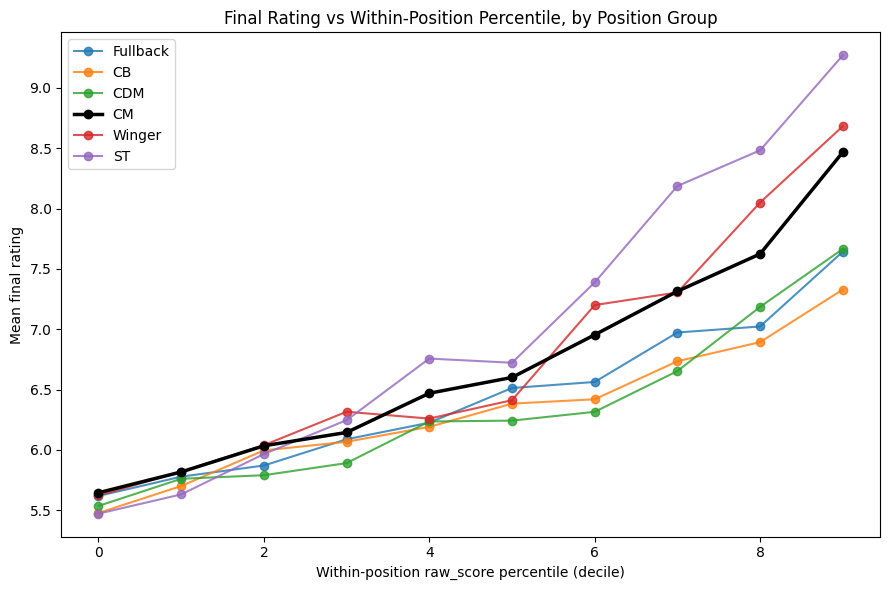

In [16]:
plt.figure(figsize=(9, 6))

for group in scale_df['position_group'].unique():
    sub = binned[binned['position_group'] == group].sort_values('percentile_bin')
    style = {'color': 'black', 'linewidth': 2.5, 'zorder': 10} if group == REFERENCE_POSITION else {'linewidth': 1.5, 'alpha': 0.8}
    plt.plot(sub['percentile_bin'], sub['mean_rating'], marker='o', label=group, **style)

plt.xlabel("Within-position raw_score percentile (decile)")
plt.ylabel("Mean final rating")
plt.title("Final Rating vs Within-Position Percentile, by Position Group")
plt.legend()
plt.tight_layout()
plt.show()

**Result: the curves track closely through the bottom 60% of the distribution,
then diverge sharply from decile 6 onward.** Through deciles 0-5 all six
positions sit close together - ST is even slightly *below* CM at the bottom
(5.47 vs 5.63). From decile 6, ST and Winger pull above CM (ST reaching 9.27 by
decile 9, Winger 8.68, against CM's 8.47) while CB, CDM, and Fullback sit
visibly below (7.32-7.68). The divergence runs in both directions around CM's
baseline, not just upward for attacking positions - worth keeping that framing
rather than only describing the top end as "inflated."


## Decomposing the Top-Decile Gap

The curve above shows *that* positions diverge at the elite end - not *why*.
Two channels could be responsible: how heavily each position's PCA weight
vector weighs goals_p90/assists_p90 within the dot product itself
(`scoring_dot_contribution`), or the separate additive goal/assist bonus
(`event_bonus`, coefficients already confirmed: ST 1.5/1.1, Winger 1.3/1.0, CM
1.0/0.75, CB 0.75/0.55, Fullback 0.5/0.4). Captured directly from the live
service via the same subclassing technique as the supremacy-scalar ablation,
rather than reimplementing the internal z-scoring/smoothing externally.


In [17]:
class DecompositionCapturingService(MatchRatingsService):
    """Captures three things per rating call: raw_score (the full pre-bonus dot
    product), the slice of raw_score specifically attributable to goals_p90/
    assists_p90 as weighted inputs, and event_bonus (the separate additive
    goal/assist bonus). Lets the dot-product weighting channel and the
    additive bonus channel be compared directly, rather than only seeing their
    combined effect on raw_score."""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.captured_raw_scores = []
        self.captured_scoring_dot_contribution = []
        self.captured_event_bonuses = []

    def _calculate_dot_product(self, z_scores, weights):
        raw_score = super()._calculate_dot_product(z_scores, weights)
        self.captured_raw_scores.append(raw_score)
        # col_names[0]=goals_p90, col_names[1]=assists_p90 - confirmed from the
        # source list that builds `weights`, same order every time.
        goals_contrib = z_scores.get("goals_p90_z", 0.0) * weights[0]
        assists_contrib = z_scores.get("assists_p90_z", 0.0) * weights[1]
        self.captured_scoring_dot_contribution.append(goals_contrib + assists_contrib)
        return raw_score

    def _apply_pos_modifiers(self, *args, **kwargs):
        base_raw_score, event_bonus = super()._apply_pos_modifiers(*args, **kwargs)
        self.captured_event_bonuses.append(event_bonus)
        return base_raw_score, event_bonus

In [18]:
decomposing_service = DecompositionCapturingService(weights, means_stds)

decomp_records = []
for match in data:
    match_overview = match['data']
    half_length = match_overview['half_length']
    for perf in match['player_performances']:
        if perf['performance_type'] != 'Outfield':
            continue
        positions = perf.get('positions_played', [])
        if len(positions) != 1:
            continue
        pos_group = POSITION_GROUP_MAP.get(positions[0])
        if pos_group is None:
            continue

        rating = decomposing_service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
        if rating is None:
            continue

        decomp_records.append({
            'match_id': match['id'], 'player_id': perf['player_id'],
            'position_group': pos_group, 'rating': rating,
            'raw_score': decomposing_service.captured_raw_scores[-1],
            'scoring_dot_contribution': decomposing_service.captured_scoring_dot_contribution[-1],
            'event_bonus': decomposing_service.captured_event_bonuses[-1],
        })

decomp_df = pd.DataFrame(decomp_records)
decomp_df['non_scoring_raw_score'] = decomp_df['raw_score'] - decomp_df['scoring_dot_contribution']

In [19]:
decomp_df['raw_score_percentile'] = decomp_df.groupby('position_group')['raw_score'].rank(pct=True) * 100
top_decile = decomp_df[decomp_df['raw_score_percentile'] >= 90]

composition = (
    top_decile.groupby('position_group')[['rating', 'non_scoring_raw_score', 'scoring_dot_contribution', 'event_bonus']]
    .mean()
    .reindex(['ST', 'Winger', 'CM', 'CB', 'CDM', 'Fullback'])  # gradient order
)
composition['n'] = top_decile.groupby('position_group').size().reindex(composition.index)
composition

,rating,non_scoring_raw_score,scoring_dot_contribution,event_bonus,n
position_group,,,,,
ST,9.270833,0.364027,4.726758e-01,2.533333,24
Winger,8.682222,0.647531,1.606187e-01,1.701778,45
CM,8.467442,0.732154,1.149118e-01,1.033721,43
CB,7.328571,0.684399,2.926667e-19,0.048810,42
CDM,7.665000,0.787766,1.821305e-02,0.135000,20
Fullback,7.636585,0.695260,1.852771e-02,0.107317,41


**Result: the additive bonus dominates, the dot-product weighting is secondary
and concentrated almost entirely in ST.** `event_bonus` at the elite tier: ST
2.53, Winger 1.70, CM 1.03, CDM 0.14, Fullback 0.11, CB 0.05 - matching the
coefficient ordering closely, both in rank and in approximate proportion.
`scoring_dot_contribution` is small everywhere except ST (0.47); Winger's is
only 0.16. `non_scoring_raw_score` - the part that should be comparable if all
positions are equally elite relative to their own peers - sits in a tight band
(0.36-0.79) with no attacking/defensive split at all. CB's
`scoring_dot_contribution` of 2.93e-19 isn't noise - it matches the
near-exactly-zero goals_p90 weight (6.9e-33) already confirmed in CB's PCA
vector; the algorithm deliberately gives CB zero credit for goals.


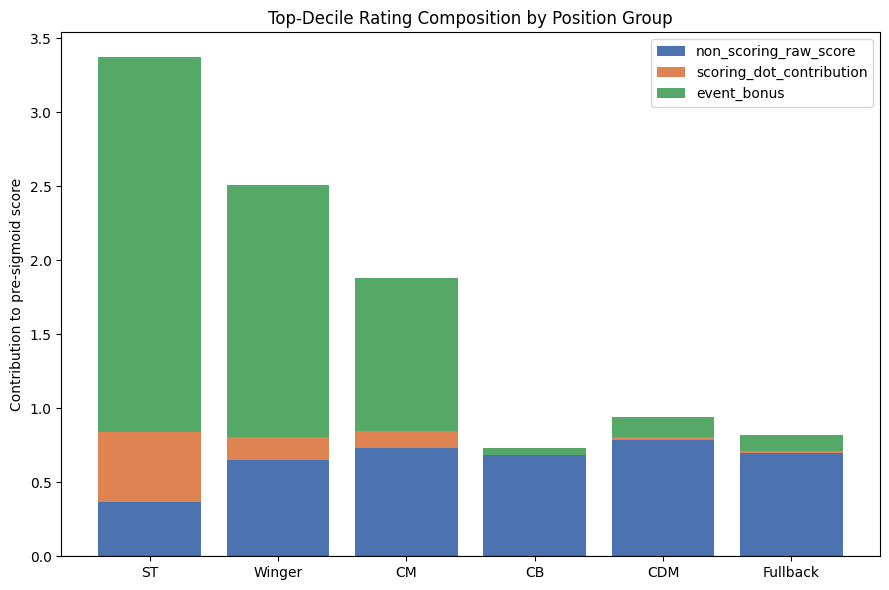

In [20]:
plt.figure(figsize=(9, 6))
positions_ordered = composition.index
bottom = np.zeros(len(positions_ordered))

for component, color in [('non_scoring_raw_score', '#4c72b0'), ('scoring_dot_contribution', '#dd8452'), ('event_bonus', '#55a868')]:
    values = composition[component].values
    plt.bar(positions_ordered, values, bottom=bottom, label=component, color=color)
    bottom += values

plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel("Contribution to pre-sigmoid score")
plt.title("Top-Decile Rating Composition by Position Group")
plt.legend()
plt.tight_layout()
plt.show()

**This decomposes the pre-sigmoid score, not the final rating** - the sigmoid's
compression means these bar heights don't map linearly onto the curve plot's
final-rating gap (ST's pre-sigmoid lead over CM here is ~1.48; its final-rating
lead was 0.80). Read this as "where the elite-tier advantage originates," not
as a literal breakdown of the rating-point gap.


In [21]:
def bootstrap_top_decile_gap(df, position_a, position_b, metric, n_resamples=N_BOOTSTRAP_RESAMPLES, seed=RANDOM_SEED):
    rng_local = np.random.default_rng(seed)
    vals_a = df[df['position_group'] == position_a][metric].values
    vals_b = df[df['position_group'] == position_b][metric].values

    point_gap = vals_a.mean() - vals_b.mean()
    boot_gaps = np.empty(n_resamples)
    for i in range(n_resamples):
        boot_gaps[i] = rng_local.choice(vals_a, size=len(vals_a), replace=True).mean() - \
                       rng_local.choice(vals_b, size=len(vals_b), replace=True).mean()
    ci_l, ci_h = np.percentile(boot_gaps, [2.5, 97.5])
    return point_gap, ci_l, ci_h

gap_results = []
for group in composition.index:
    if group == REFERENCE_POSITION:
        continue
    for metric in ['event_bonus', 'rating']:
        gap, ci_l, ci_h = bootstrap_top_decile_gap(top_decile, group, REFERENCE_POSITION, metric)
        gap_results.append({'position_group': group, 'metric': metric, 'gap_vs_cm': gap, 'ci_low': ci_l, 'ci_high': ci_h})

gap_df = pd.DataFrame(gap_results)
gap_df

,position_group,metric,gap_vs_cm,ci_low,ci_high
0,ST,event_bonus,1.499612,0.899707,2.123280
1,ST,rating,0.803391,0.514600,1.094576
2,Winger,event_bonus,0.668057,0.218678,1.136717
3,Winger,rating,0.214780,-0.121764,0.552833
4,CB,event_bonus,-0.984911,-1.228185,-0.737237
5,CB,rating,-1.138870,-1.428602,-0.827241
6,CDM,event_bonus,-0.898721,-1.151813,-0.649417
7,CDM,rating,-0.802442,-1.150814,-0.438369
8,Fullback,event_bonus,-0.926404,-1.176409,-0.681050
9,Fullback,rating,-0.830856,-1.120478,-0.521659


**At this stage (raw_score ranking), event_bonus gaps all exclude zero, but
rating gaps are mixed.** ST (+0.80, CI[0.51,1.09]), CB (-1.14, CI[-1.43,-0.83]),
CDM (-0.80, CI[-1.15,-0.44]), and Fullback (-0.83, CI[-1.12,-0.52]) all survive
cleanly. **Winger's rating gap does not** (+0.21, CI[-0.12,0.55]) despite its
event_bonus gap surviving (+0.67, CI[0.22,1.14]) - the bonus advantage is real,
but doesn't (yet, at this ranking) translate into a statistically distinguishable
final-rating advantage. ST's median event_bonus (2.00) sitting close to its mean
(2.53, checked next cell) rules out a couple of hat-trick games driving the
average.

**This entire result turns out to be superseded by the non-scoring re-rank
below** - kept here rather than deleted, since the correction and *why* it
mattered is itself part of the finding.


In [22]:
st_bonus = top_decile[top_decile['position_group'] == 'ST']['event_bonus']
print(f"ST top-decile event_bonus - mean: {st_bonus.mean():.3f}, median: {st_bonus.median():.3f}, n: {len(st_bonus)}")

ST top-decile event_bonus - mean: 2.533, median: 2.000, n: 24


Confirmed - mean (2.533) and median (2.000) sit close together. ST's elite-tier
bonus figure is representative of the group, not skewed by a small number of
exceptional performances.


## Re-Ranking on Non-Scoring Quality Only

The decomposition above showed `raw_score` already includes each position's own
weighting of goals_p90/assists_p90 - meaning "top decile by raw_score" partially
self-selects for high-scoring performances among attacking positions before the
separate additive bonus is even considered. Re-ranking on `non_scoring_raw_score`
(raw_score minus the goals/assists dot-product contribution) removes that
self-selection, giving a percentile definition of "elite" that's genuinely
independent of scoring for every position.


In [23]:
decomp_df['non_scoring_percentile'] = decomp_df.groupby('position_group')['non_scoring_raw_score'].rank(pct=True) * 100
top_decile_clean = decomp_df[decomp_df['non_scoring_percentile'] >= 90]

composition_clean = (
    top_decile_clean.groupby('position_group')[['rating', 'non_scoring_raw_score', 'scoring_dot_contribution', 'event_bonus']]
    .mean()
    .reindex(['ST', 'Winger', 'CM', 'CB', 'CDM', 'Fullback'])
)
composition_clean['n'] = top_decile_clean.groupby('position_group').size().reindex(composition_clean.index)
composition_clean

,rating,non_scoring_raw_score,scoring_dot_contribution,event_bonus,n
position_group,,,,,
ST,8.241667,0.480727,1.297535e-01,1.091667,24
Winger,8.104444,0.696363,6.350941e-02,1.033333,45
CM,8.037209,0.773193,5.128892e-02,0.646512,43
CB,7.328571,0.684399,2.926667e-19,0.048810,42
CDM,7.665000,0.787766,1.821305e-02,0.135000,20
Fullback,7.536585,0.701549,9.049995e-03,0.068293,41


**Result: this materially revises the headline finding.** Under the stricter
non-scoring ranking, ST's rating advantage over CM collapses from +0.80 to
**+0.20** (8.24 vs 8.04); Winger's collapses from +0.21 to **+0.07** (8.10 vs
8.04) - most of the original "attacking inflation" was self-selection, not bonus
inflation. **CB, CDM, and Fullback's deficits barely move** (-0.71, -0.37, -0.50
vs the original -1.14/-0.80/-0.83) - this part of the finding was never a
self-selection artefact. Even CM (the neutral-baseline position, not an
attacking one) still earns 0.65 of bonus credit at its own non-scoring-elite
tier, against CB's 0.05 - the deficit is about defensive roles structurally
rarely producing the triggering event, not about attacking positions being
favoured by the ranking.


Thin bins (n < 15): 0 / 60


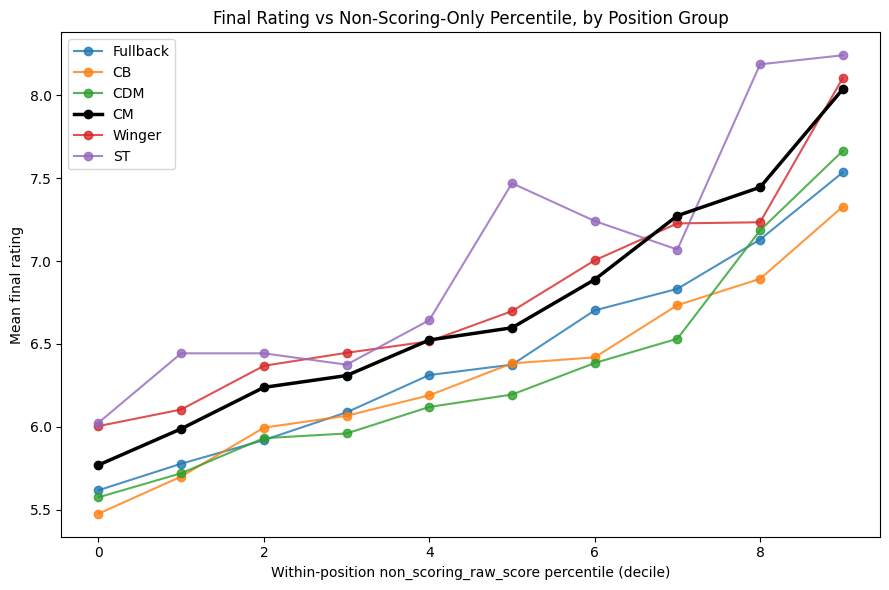

In [24]:
decomp_df['non_scoring_bin'] = decomp_df.groupby('position_group')['non_scoring_percentile'].transform(
    lambda x: pd.cut(x, bins=N_PERCENTILE_BINS, labels=False, include_lowest=True)
)
binned_clean = (
    decomp_df.groupby(['position_group', 'non_scoring_bin'])
    .agg(mean_rating=('rating', 'mean'), n=('rating', 'size'))
    .reset_index()
)
print(f"Thin bins (n < {MIN_SAMPLES_PER_BIN}): {(binned_clean['n'] < MIN_SAMPLES_PER_BIN).sum()} / {len(binned_clean)}")

plt.figure(figsize=(9, 6))
for group in decomp_df['position_group'].unique():
    sub = binned_clean[binned_clean['position_group'] == group].sort_values('non_scoring_bin')
    style = {'color': 'black', 'linewidth': 2.5, 'zorder': 10} if group == REFERENCE_POSITION else {'linewidth': 1.5, 'alpha': 0.8}
    plt.plot(sub['non_scoring_bin'], sub['mean_rating'], marker='o', label=group, **style)
plt.xlabel("Within-position non_scoring_raw_score percentile (decile)")
plt.ylabel("Mean final rating")
plt.title("Final Rating vs Non-Scoring-Only Percentile, by Position Group")
plt.legend()
plt.tight_layout()
plt.show()

**Result: the divergence is visible across the whole distribution, not
confined to the elite tier, and isn't monotonic.** ST already sits above CM at
decile 0 (6.02 vs 5.77). The single biggest gap in the plot is at decile 5
(ST 7.47 vs CM 6.60, +0.87), not decile 9. This makes sense once stated plainly:
non-scoring ranking deliberately ignores whether a performance included a goal,
so even a bottom-decile-by-non-scoring-quality ST or Winger performance still
has some base-rate chance of having scored - strikers and wingers simply
generate scoring events more often per match, regardless of overall quality
tier, than defenders do. The honest characterisation broadens from "elite-tier
inflation" to a pervasive lift tied to how often each role incidentally
produces a bonus-triggering event, visible everywhere in the distribution, not
a phenomenon specific to the very best performances.


In [25]:
gap_results_clean = []
for group in composition_clean.index:
    if group == REFERENCE_POSITION:
        continue
    for metric in ['event_bonus', 'rating']:
        gap, ci_l, ci_h = bootstrap_top_decile_gap(top_decile_clean, group, REFERENCE_POSITION, metric)
        gap_results_clean.append({'position_group': group, 'metric': metric, 'gap_vs_cm': gap, 'ci_low': ci_l, 'ci_high': ci_h})

gap_df_clean = pd.DataFrame(gap_results_clean)
gap_df_clean

,position_group,metric,gap_vs_cm,ci_low,ci_high
0,ST,event_bonus,0.445155,0.046892,0.847495
1,ST,rating,0.204457,-0.352042,0.735184
2,Winger,event_bonus,0.386822,0.037926,0.741856
3,Winger,rating,0.067235,-0.354943,0.484014
4,CB,event_bonus,-0.597702,-0.818443,-0.389145
5,CB,rating,-0.708638,-1.039102,-0.374639
6,CDM,event_bonus,-0.511512,-0.745291,-0.283945
7,CDM,rating,-0.372209,-0.746529,0.024895
8,Fullback,event_bonus,-0.578219,-0.800518,-0.376912
9,Fullback,rating,-0.500624,-0.840337,-0.171122


**Result: the asymmetry survives, but doesn't split cleanly along
attacking-vs-defensive lines - it's the defensive side that's robustly
confirmed, the attacking side is not.**

`event_bonus` gaps exclude zero for all six comparisons - expected, since the
coefficients are fixed multipliers and any reasonable real sample reflects that
difference.

`rating` gaps tell a more precise story:
- **CB (-0.71, CI[-1.04,-0.37]) and Fullback (-0.50, CI[-0.84,-0.17]): robustly
  survive.** Real, statistically defensible rating disadvantage.
- **CDM (-0.37, CI[-0.75, 0.025]): borderline** - upper bound sits just above
  zero. Can't confidently claim or rule out a real effect.
- **ST (+0.20, CI[-0.35, 0.74]) and Winger (+0.07, CI[-0.35, 0.48]): neither
  survives.** Despite a confirmed bonus-channel advantage, neither translates
  into a statistically distinguishable final-rating advantage at this n.

**Two different kinds of non-finding here, worth not flattening together.**
Winger's point estimate (+0.07) is itself tiny - this isn't a power problem,
it's a result saying there's essentially nothing to find. ST's point estimate
(+0.20) is more substantial but sits inside a CI wide enough to include zero -
closer to a genuine power problem at n=24 than a "no effect" result.

**Net conclusion: the defensive-side deficit (CB, and to a lesser extent
Fullback/CDM) is the part of this finding that's actually proven. The
attacking-side advantage is mechanistically real - the bonus coefficients are
confirmed, fixed, and large - but does not currently survive as a statistically
confirmed rating-level effect.** That's a meaningfully more precise claim than
where this analysis started.


## Caveats

- **CAM excluded by deliberate choice, not oversight.** CAM's profile (0.9 goal
  coefficient, the most generous z-score floors of any position per the
  service's own docstrings) makes it a real candidate for showing this effect
  even more sharply than ST - left untested as a scoping decision, not because
  it seemed unimportant.
- **GK is structurally out of scope for this exact method, not just untested.**
  GK doesn't route through `_calculate_dot_product`/`_apply_pos_modifiers` at
  all - it uses an entirely separate formula (`gk_heuristic`). The conceptual
  question ("is it easier for a GK to hit 9.0 than a CB") is still meaningful
  and still unanswered; answering it would need a different capture design
  built around GK's own structure, not an extension of this one.
- **The decomposition (composition/composition_clean tables) breaks down the
  pre-sigmoid score, not the final rating.** The sigmoid's compression means
  pre-sigmoid contribution sizes don't map linearly onto final-rating gaps -
  confirmed directly (ST's pre-sigmoid lead over CM was ~1.48, its final-rating
  lead was 0.80). Useful for "where does the advantage originate," not a literal
  accounting of the rating-point gap.
- **Sample sizes at the top decile are thin for some groups** - ST n=24, CDM
  n=20 in the original ranking (similar order in the corrected one). The
  bootstrap CIs already reflect this (visible in how wide CDM's and ST's
  intervals are relative to CB's or Fullback's), but it's worth remembering
  when reading point estimates for these two groups specifically.
- **Single-position restriction excludes multi-position-blended performances**
  (1.2-6.6% per group, CDM losing the largest share) - necessary to avoid
  `_calculate_dot_product`'s per-position-loop ambiguity for blended players,
  but means this analysis says nothing about how the cosine-similarity blending
  itself might affect scale comparability for multi-position players
  specifically.
- **The non-scoring re-rank materially changed the conclusion once - worth
  remembering it could move again under a different design choice.** The
  correction here (re-ranking on `non_scoring_raw_score` instead of `raw_score`)
  resolved one specific self-selection concern. Other reasonable redefinitions
  of "elite relative to peers" weren't tried, and might shift the picture
  further - this isn't claimed as the final word on how to operationalise the
  comparison, just the most defensible version built and tested here.


## Conclusions

**What this notebook set out to test:** whether the rating scale means the same
thing across positions - is it easier for a striker to reach a given rating
than a centre-back, for an equivalently elite-relative-to-peers underlying
performance? Not covered by any single section of the critical review (3.0-3.9),
though motivated directly by 3.5's framing of the goal/assist coefficients as
exactly the kind of hand-set "taste" parameter that section exists to scrutinise.

### What's confirmed

**The additive goal/assist bonus is the dominant mechanism behind any
cross-position scale divergence - the dot-product's own weighting of
goals/assists is a secondary, mostly ST-specific effect.** Decomposing the
pre-sigmoid score showed `event_bonus` accounts for the large majority of the
elite-tier gap; `non_scoring_raw_score` (everything else) sits in a tight,
comparable band across all six positions with no attacking/defensive split.

**Defensive positions are structurally excluded from bonus credit, and this is
the part of the finding that survives full statistical scrutiny.** CB and
Fullback both show a real, bootstrap-confirmed rating disadvantage relative to
CM (the system's own designated neutral baseline) even when "elite" is defined
using only non-scoring inputs (CB -0.71 CI[-1.04,-0.37], Fullback -0.50
CI[-0.84,-0.17]). This isn't about the ranking definition or self-selection -
it survived the correction that materially weakened the attacking side of the
finding. CDM sits at a borderline -0.37 (CI[-0.75, 0.025]) - plausibly a smaller
version of the same effect, not yet confirmed at this n.

### What's real but not (yet) statistically confirmed

**The attacking-side advantage is mechanistically demonstrated but does not
currently survive as a confirmed rating-level effect.** ST and Winger's bonus
coefficients are real, fixed, and large (1.5/1.1 and 1.3/1.0 respectively,
against CM's 1.0/0.75) - and the original raw_score-ranked analysis showed a
large final-rating gap. But re-ranking on non-scoring quality alone collapsed
most of that gap (ST +0.80 -> +0.20, Winger +0.21 -> +0.07), revealing it was
substantially self-selection: ranking by raw_score partly just picked out
performances that happened to include goals. The residual gaps, bootstrapped,
don't exclude zero for either position. Winger's near-zero point estimate
reads as a genuine null result; ST's larger-but-uncertain estimate reads more
like an underpowered test at n=24 than a confirmed absence of effect.

### What's still open

**CAM was deliberately not tested** - its coefficient profile makes it a
plausible candidate to show this pattern even more sharply, left as a clear
next step rather than an oversight.

**GK cannot be tested with this exact method** - a structurally different
question requiring a different design, not just an extension of this one.

**Whether the defensive deficit is itself a problem is a separate, unanswered
design question.** This notebook establishes that CB/Fullback (and plausibly
CDM) structurally cannot earn bonus credit regardless of performance quality -
it doesn't establish whether that's a flaw to fix or a defensible reflection of
the role (a centre-back scoring is genuinely incidental to the job in a way a
striker's goals are not). That's a judgement call for whoever maintains the
algorithm, informed by this evidence rather than settled by it.

### What this means for the algorithm overall

The original hunch - "strikers feel overrated, the goal bonus seems too
generous" - turns out to be more precisely a story about defensive positions
being locked out of bonus credit by construction, with the attacking-side
half of the intuition real in mechanism but not yet confirmed in outcome at
current sample sizes. This is a good, concrete, motivated entry point into 3.5:
the goal/assist coefficients are now a specifically flagged hand-set parameter
to interrogate in the broader sensitivity sweep, rather than one constant among
many to check generically.
